# Module 17 - Convolutional Neural Networks (CNNs)
---

## Agenda

1. Why do regular neural networks struggle with images?
2. The convolution operation
3. Pooling layers
4. Putting it all together: the CNN architecture
5. Training a CNN on MNIST
6. Inspecting what the network learns
7. Summary and next steps

---

## Setup

Run the cell below to import everything we need. `cnn_plots.py` lives in the same folder as this notebook and contains all the plotting helpers we will use throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Local plotting utilities
import cnn_plots as cp

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device : {DEVICE}")

PyTorch version : 2.8.0
Device          : cpu


---

## 1. Why do regular neural networks struggle with images?

In the previous two weeks you built feed-forward (fully-connected) networks. Let's think about what happens when we apply one to a modest image.

| Image size | Pixels | Parameters in first FC layer (256 units) |
|:----------:|:------:|:-----------------------------------------:|
| 28 x 28 (MNIST) | 784 | ~200 k |
| 224 x 224 x 3 (ImageNet) | 150,528 | ~38 M |
| 1920 x 1080 x 3 (HD photo) | 6,220,800 | ~1.6 **B** |

**Three big problems:**

1. **Parameter explosion** : the network becomes enormous and slow to train.
2. **Spatial structure is ignored** : a fully-connected layer treats pixel (0,0) and pixel (27,27) as completely unrelated, but nearby pixels usually share context.
3. **No translation invariance** : if a digit shifts one pixel to the right, a FC net may not recognise it any more.

CNNs solve all three by sharing weights spatially through *convolution*.

---

## 2. The Convolution Operation

A **convolutional layer** slides a small matrix of weights called a **kernel** (or filter) across the input. At each position it computes a dot product between the kernel and the patch of input it currently covers. The result is a **feature map**.

Key ideas:
- The same kernel weights are *reused* at every position. This is **weight sharing**, which is why CNNs have so many fewer parameters than FC layers.
- Each kernel specialises in detecting a particular local pattern (edges, corners, textures, ...).
- A convolutional layer typically learns *many* kernels in parallel, producing one feature map per kernel.

**PyTorch API:**
```python
nn.Conv2d(
    in_channels  = 1,    # e.g. 1 for greyscale, 3 for RGB
    out_channels = 32,   # number of filters to learn
    kernel_size  = 3,    # 3x3 kernel
    padding      = 0,    # no padding (output shrinks by 2 in each dim)
)
```

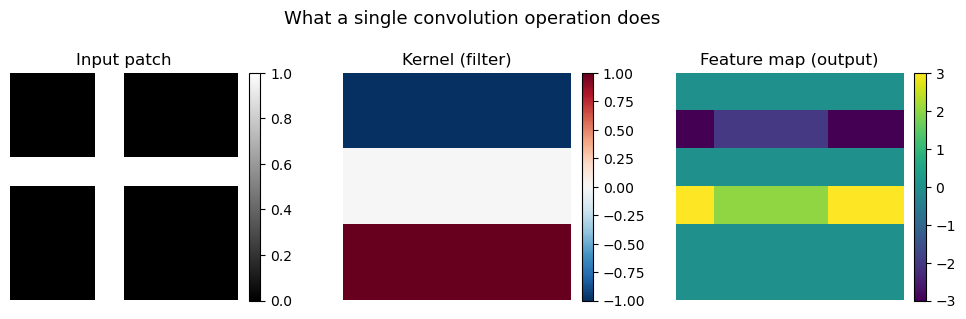

In [2]:
# Build a small synthetic 8x8 image patch (a simple cross shape)
patch = np.zeros((8, 8), dtype=float)
patch[3, :] = 1.0   # horizontal bar
patch[:, 3] = 1.0   # vertical bar

# A horizontal-edge-detecting kernel
kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=float)

fig = cp.plot_convolution_demo(patch, kernel)
plt.show()

The feature map (right panel) highlights the row where the horizontal bar sits.  The kernel has effectively "found" the horizontal edge by producing high positive values along it.  A different kernel would respond to different features.

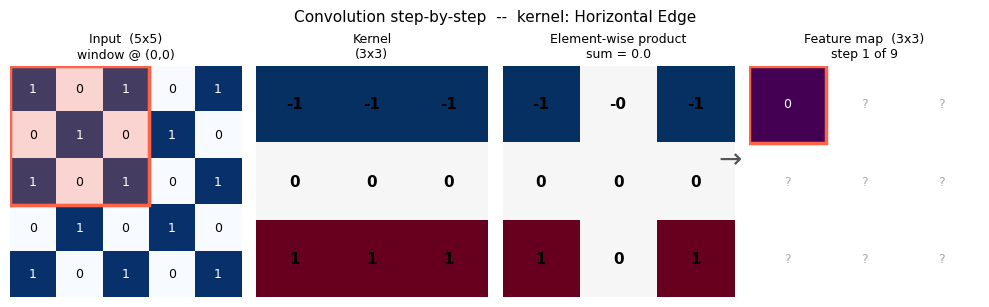

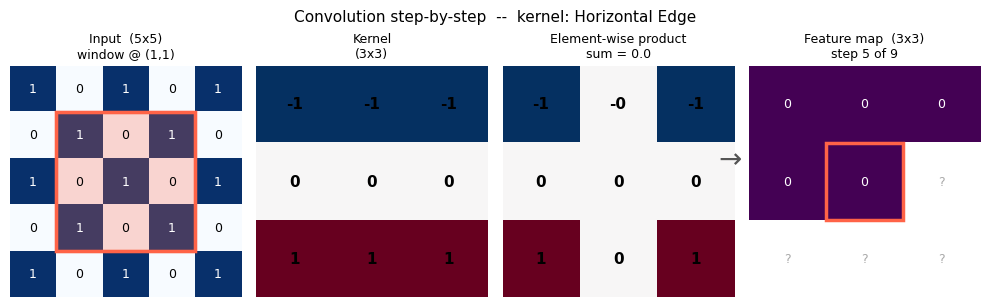

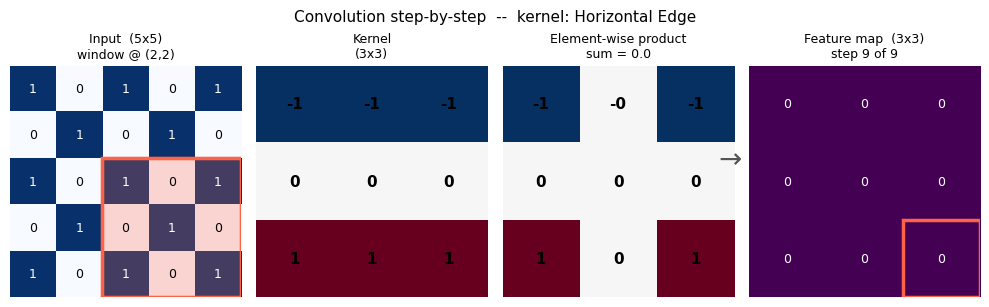

In [9]:
image = np.array([
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 0, 1],
], dtype=float)

kernel = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float)

# Walk through steps 0, 4, and 8 to show the progression
for step in [0, 4, 8]:
    fig = cp.plot_convolution_steps(image, kernel, step=step,
                                    kernel_name="Horizontal Edge")
    plt.show()

### 2.1 Kernels on a real image

We can load a single MNIST digit and manually apply classic Sobel edge-detection kernels to see the same idea at work on a real image.

Label: 5


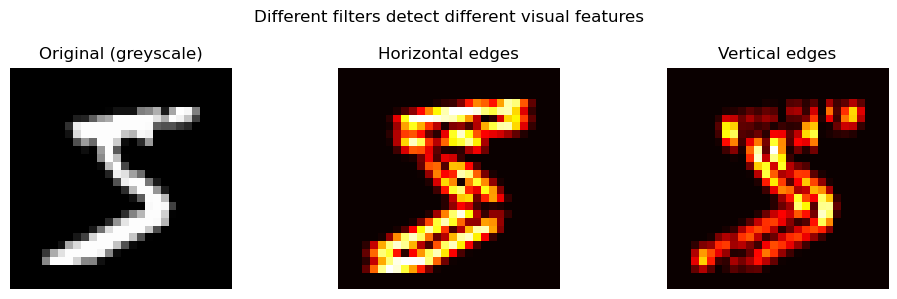

In [3]:
# Download MNIST (only the first time; cached afterwards)
_mnist_raw = torchvision.datasets.MNIST(
    root="./data", train=True, download=True,
    transform=transforms.ToTensor()
)

# Grab a single digit image as a numpy array
sample_img, sample_label = _mnist_raw[0]
sample_np = sample_img.squeeze().numpy()   # shape (28, 28), values in [0, 1]

print(f"Label: {sample_label}")
fig = cp.plot_edge_filters(sample_np)
plt.show()

The horizontal edge filter lights up along rows where pixel intensity changes sharply (the top and bottom strokes of the digit). The vertical edge filter responds to the left and right strokes. A CNN stacks dozens of such filters and *learns* their exact weights from data rather than handcrafting them.

---

## 3. Pooling Layers

After convolution we typically apply a **pooling** layer.  The most common variant is **max pooling**: divide the feature map into non-overlapping regions and keep only the maximum value in each region.

Benefits:
- **Downsampling** : reduces the spatial size of the representation, cutting computation.
- **Translation invariance** : if a feature shifts slightly, the maximum in its region will likely still be captured.

**PyTorch API:**
```python
nn.MaxPool2d(kernel_size=2, stride=2)  # halves height and width
```

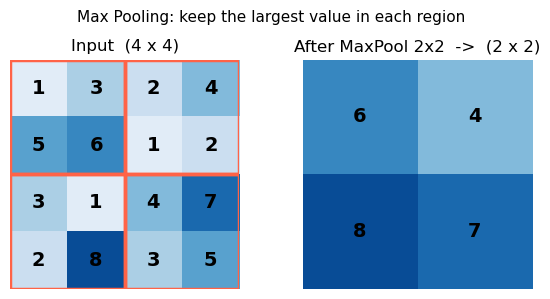

In [4]:
fig = cp.plot_pooling_demo()
plt.show()

Each red-bordered 2×2 block is reduced to its single maximum value. The output is half the size in each spatial dimension, but the most prominent activations are preserved.

---

## 4. The Full CNN Architecture

A standard CNN stacks convolutional blocks (Conv -> ReLU -> Pool) before finishing with one or more fully connected layers for classification.

- **Early layers** learn low-level features: edges, corners, colour blobs.
- **Middle layers** combine those into parts: curves, textures, simple shapes.
- **Late layers** assemble parts into object-level concepts.

THis shows the architecture we will train on MNIST.

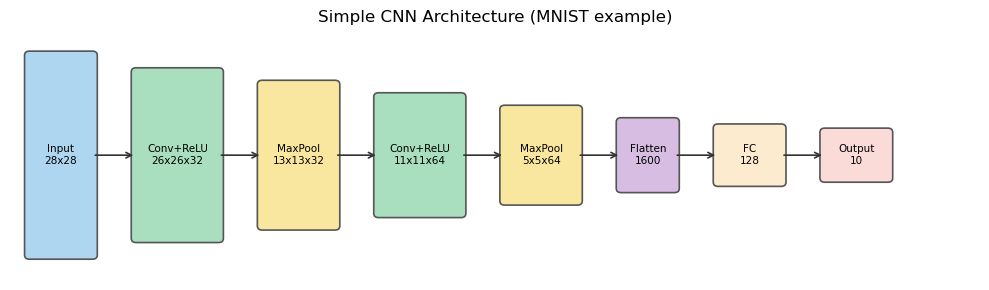

In [5]:
fig = cp.plot_cnn_architecture()
plt.show()

### Parameter count comparison

Let's count the trainable parameters in our CNN versus a fully connected network of similar depth.

In [6]:
# ---------- CNN -------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3) # -> (32, 26, 26)
        self.pool  = nn.MaxPool2d(2, 2)             # -> (32, 13, 13)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # -> (64, 11, 11)
        # after second pool: (64, 5, 5)
        self.fc1   = nn.Linear(64 * 5 * 5, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# ---------- Fully-connected baseline ------------------------
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


cnn = SimpleCNN()
mlp = SimpleMLP()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"CNN parameters : {count_params(cnn):,}")
print(f"MLP parameters : {count_params(mlp):,}")

CNN parameters : 225,034
MLP parameters : 535,818


Despite learning spatial structure, the CNN uses fewer parameters than the MLP.  Weight sharing across spatial positions is the key reason.

---

## 5. Training on MNIST

MNIST contains 60,000 training images and 10,000 test images of handwritten digits (0-9), each 28×28 pixels in greyscale. It is the classic benchmark for image classifiers.

We will:
1. Load and normalise the data.
2. Train `SimpleCNN` for a few epochs.
3. Evaluate on the test set.
4. Plot training curves and sample predictions.

In [10]:
# Normalise: subtract mean (0.1307) and divide by std (0.3081). These are standard MNIST values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

CLASS_NAMES = [str(i) for i in range(10)]

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples : 60000
Test samples     : 10000
Batches per epoch: 938


In [12]:
CLASS_NAMES

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

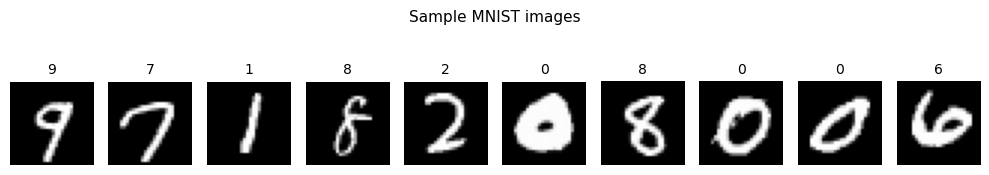

In [13]:
# Show a few raw training images (before normalisation, for legibility)
raw_loader = DataLoader(
    torchvision.datasets.MNIST(root="./data", train=True, download=False,
                               transform=transforms.ToTensor()),
    batch_size=10, shuffle=True
)
raw_imgs, raw_labels = next(iter(raw_loader))

fig, axes = plt.subplots(1, 10, figsize=(10, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(raw_imgs[i].squeeze(), cmap="gray")
    ax.set_title(str(raw_labels[i].item()), fontsize=10)
    ax.axis("off")
fig.suptitle("Sample MNIST images", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad() # stop gradient computation
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100.0 * correct / total


# ---- Training run ---
NUM_EPOCHS = 5

model = SimpleCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_acc = evaluate(model, test_loader, criterion, DEVICE)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS}  "
          f"Train loss: {tr_loss:.4f}, acc: {tr_acc:.1f}%  "
          f"Val loss: {va_loss:.4f}, acc: {va_acc:.1f}%")

Epoch 1/5  Train loss: 0.1376, acc: 95.9%  Val loss: 0.0468, acc: 98.5%
Epoch 2/5  Train loss: 0.0426, acc: 98.7%  Val loss: 0.0354, acc: 98.9%
Epoch 3/5  Train loss: 0.0296, acc: 99.0%  Val loss: 0.0288, acc: 99.1%
Epoch 4/5  Train loss: 0.0218, acc: 99.3%  Val loss: 0.0327, acc: 99.0%
Epoch 5/5  Train loss: 0.0159, acc: 99.5%  Val loss: 0.0323, acc: 99.1%


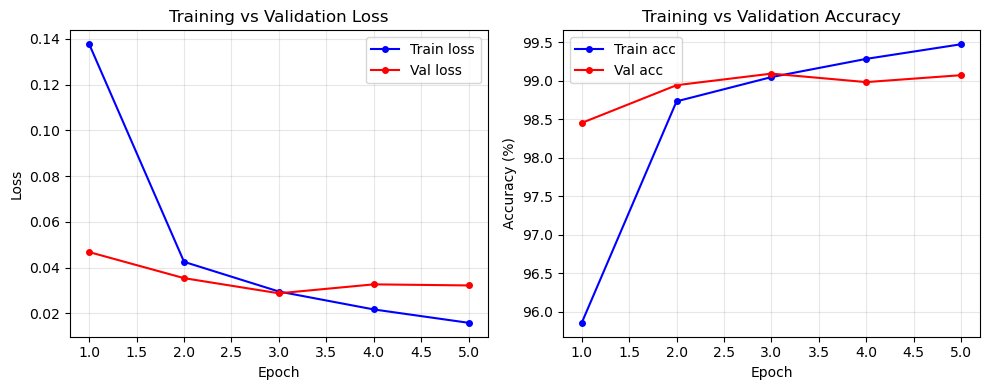

In [16]:
fig = cp.plot_training_curves(train_losses, val_losses, train_accs, val_accs)
plt.show()

**Reading the curves:**

- Both loss curves should be decreasing and the accuracy curves increasing across epochs, which confirms the model is learning.
- If training and validation curves track closely the model is generalising well.  A large gap between them would indicate overfitting.
- Final validation accuracy on MNIST with this small CNN typically lands in the **98-99%** range after 5 epochs, which is a strong result for a simple model trained from scratch.

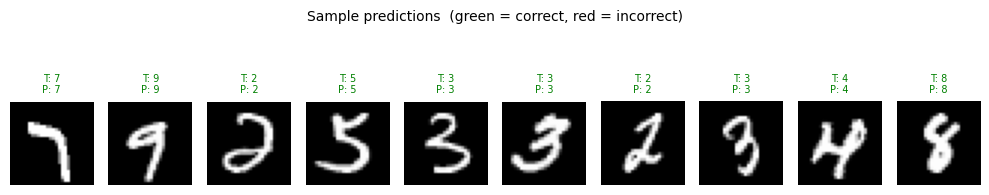

In [17]:
# Collect a batch of test images and run inference
model.eval()
batch_imgs, batch_labels = next(iter(
    DataLoader(test_dataset, batch_size=10, shuffle=True)
))

with torch.no_grad():
    logits = model(batch_imgs.to(DEVICE))
    preds  = logits.argmax(dim=1).cpu().numpy()

# Convert normalised tensors back to [0,1] for display
display_imgs = batch_imgs.numpy()  # (10, 1, 28, 28)
display_imgs = (display_imgs * 0.3081) + 0.1307   # undo normalisation
display_imgs = np.clip(display_imgs, 0, 1)

fig = cp.plot_predictions(
    display_imgs,
    batch_labels.numpy(),
    preds,
    CLASS_NAMES
)
plt.show()

The model should correctly classify almost every digit in this sample.  Any red-titled images are mistakes. Look at those and see if even a human might find them ambiguous.

---

## 6. Inspecting What the Network Learns

A big advantage of CNNs is interpretability compared to flat FC networks. We can look directly at the learned filter weights and at the feature maps they produce.

### 6.1 Learned filters in the first layer

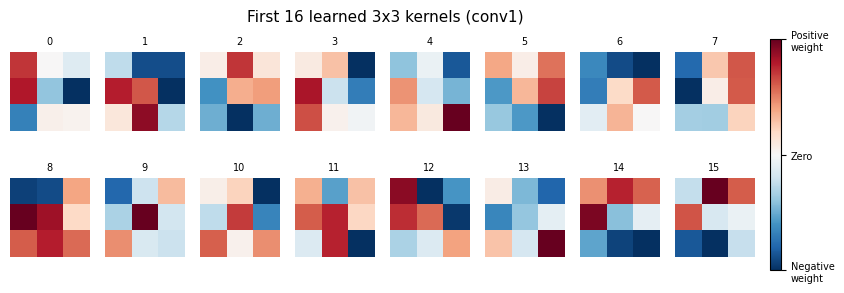

In [21]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Extract the 32 learned 3x3 kernels from conv1
filters = model.conv1.weight.data.cpu().numpy()  # shape (32, 1, 3, 3)
filters_2d = filters[:, 0, :, :]  # drop channel dim -> (32, 3, 3)

# Show the first 16
n_show = 16
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        vmax = np.abs(filters_2d[i]).max()
        ax.imshow(filters_2d[i], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"{i}", fontsize=7)
    ax.axis("off")

# Add a colorbar using a normalisation centred on zero
norm = mcolors.Normalize(vmin=-1, vmax=1)
sm   = cm.ScalarMappable(cmap="RdBu_r", norm=norm)
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["Negative\nweight", "Zero", "Positive\nweight"], fontsize=7)

fig.suptitle("First 16 learned 3x3 kernels (conv1)", fontsize=11)
plt.show()

Even after only 5 epochs on a small greyscale dataset, many filters show clear directional structure. You can see horizontal bars, vertical bars, and diagonal gradients, similar to the hand-crafted Sobel kernels we looked at earlier (sort of). The network discovered these patterns automatically by minimising cross-entropy loss.

### 6.2 Feature maps for a single image

We can also feed a single image through the network and inspect the intermediate activations to see what each layer "sees".

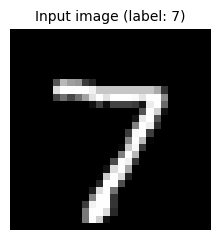

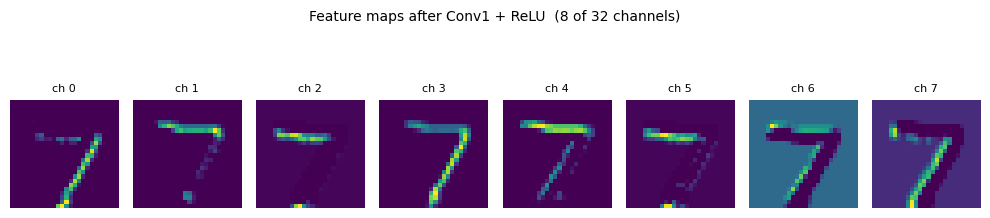

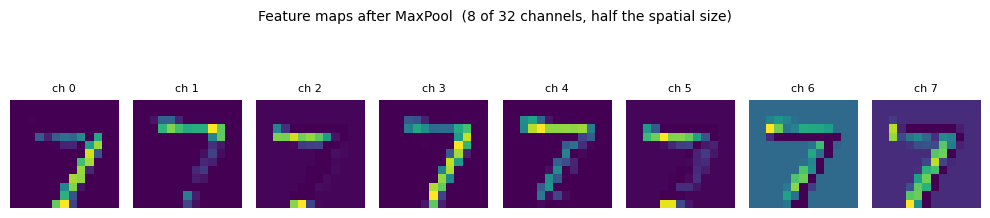

In [22]:
# Pick one test image
single_img, single_label = test_dataset[0]
single_tensor = single_img.unsqueeze(0).to(DEVICE)  # (1, 1, 28, 28)

# Run through conv1 -> ReLU -> pool to get the first-layer feature maps
model.eval()
with torch.no_grad():
    after_conv1 = F.relu(model.conv1(single_tensor))  # (1, 32, 26, 26)
    after_pool1 = model.pool(after_conv1)              # (1, 32, 13, 13)

fmaps_conv1 = after_conv1.squeeze(0).cpu().numpy()    # (32, 26, 26)
fmaps_pool1 = after_pool1.squeeze(0).cpu().numpy()    # (32, 13, 13)

# Display the input
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(single_img.squeeze(), cmap="gray")
ax.set_title(f"Input image (label: {single_label})", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

# Display first 8 feature maps after conv1
fig = cp.plot_feature_maps(fmaps_conv1, max_maps=8,
                           title="Feature maps after Conv1 + ReLU  (8 of 32 channels)")
plt.show()

# Display first 8 feature maps after pool1
fig = cp.plot_feature_maps(fmaps_pool1, max_maps=8,
                           title="Feature maps after MaxPool  (8 of 32 channels, half the spatial size)")
plt.show()

- After Conv1+ReLU each channel highlights a different aspect of the digit: some respond to its top strokes, others to the sides, others to the interior.
- After MaxPool the spatial dimensions are halved (26×26 -> 13×13) but the key activated regions are still clearly present.
- This progressive abstraction: preserving what matters while discarding unnecessary detail. This is the core of how CNNs work.

---

## 7. Summary

| Concept | Key takeaway |
|:--------|:-------------|
| Convolution | Slides a small kernel across the image; same weights reused everywhere (weight sharing) |
| Feature maps | Each kernel produces one output channel that highlights a particular local pattern |
| ReLU | Applied after each conv layer; introduces non-linearity |
| Max pooling | Downsamples spatial dimensions; builds in local translation invariance |
| Flatten + FC | After the conv blocks, flatten into a vector and classify with standard FC layers |
| Parameter efficiency | CNNs have far fewer parameters than FC nets for image inputs |
